# 4大主流血統 舞台別成績による小グルーピング分析

任意の主流血統（Turn-To系 / Northern Dancer系 / Native Dancer系 / Nasrullah系）を選択し、
配下の種牡馬を「各舞台条件での勝率・連対率」の統計量でクラスタリングすることで
統計的に意味のある小グループを発見する。

## 分析フロー
1. **データ結合**: レース結果 × 血統カテゴリ × 系統lineage
2. **特徴量構築**: 競馬場・馬場・距離・馬場状態別の勝率偏差
3. **次元削減**: PCA で主要成分を抽出
4. **クラスタリング**: K-means + 階層クラスタリング
5. **解釈**: 各クラスタの特徴プロファイル可視化

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import japanize_matplotlib
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

# 日本語フォント設定
# sns.set_theme がフォントをリセットするため、set_theme の後に japanize を再適用する
sns.set_theme(style='whitegrid')
japanize_matplotlib.japanize()   # IPAexGothic を再設定
_jp_font = matplotlib.rcParams['font.family']
if isinstance(_jp_font, list):
    _jp_font = _jp_font[0]
plt.rcParams['axes.unicode_minus'] = False
print(f'使用フォント: {_jp_font}')

ROOT = Path('../..') if Path('../../data').exists() else (Path('..') if Path('../data').exists() else Path('.'))
IDX  = ROOT / 'data/research/pedigree_race_index'
print('ROOT:', ROOT.resolve())
import umap as umap_lib


使用フォント: IPAexGothic
ROOT: /home/hirokiakataoka/project/myproject/keiba-vpn


## 1. データ読み込み

In [2]:
print('レース結果を読み込み中...')
race = pd.read_parquet(IDX / 'race_result_slim.parquet')
race['date'] = pd.to_datetime(race['date'])
race['venue']   = race['venue'].astype(str)
race['surface'] = race['surface'].astype(str)
race['track_condition'] = race['track_condition'].astype(str)
race['win']    = (race['finish_position'] == 1).astype(int)
race['place']  = (race['finish_position'] <= 3).astype(int)
race['valid']  = (race['finish_position'] > 0).astype(int)  # 競走除外/中止を除外
race = race[race['valid'] == 1].copy()
# ── オッズフィルタ ──────────────────────────────────────────────
# race_result_flat からオッズを読み込み（race_id × horse_id で結合）
ODDS_MAX = 20.0   # ← この値以下のオッズのみを分析対象にする

print('オッズデータを読み込み中...')
_tables_dir = ROOT / 'data/local/tables'
_odds_dfs = []
for _f in sorted(_tables_dir.glob('*/race_result_flat.parquet')):
    try:
        _odds_dfs.append(pd.read_parquet(_f, columns=['race_id', 'horse_id', 'odds', 'bracket_number', 'field_size', 'sex_age', 'weather']))
    except Exception:
        pass
if _odds_dfs:
    odds_df = pd.concat(_odds_dfs, ignore_index=True)
    odds_df['race_id']  = odds_df['race_id'].astype(str)
    odds_df['horse_id'] = odds_df['horse_id'].astype(str)
    race = race.merge(odds_df, on=['race_id', 'horse_id'], how='left')
    before = len(race)
    race = race[race['odds'].fillna(999) <= ODDS_MAX].copy()
    # 枠番・頭数・馬齢・季節カラムを追加
    race['bracket_number'] = race['bracket_number'].fillna(0).astype(int)
    race['field_size']     = race['field_size'].fillna(0).astype(int)
    # 枠番グループ
    race['bracket_grp'] = race['bracket_number'].apply(
        lambda x: '内枠' if x in [1,2,3] else ('外枠' if x in [7,8] else '中枠'))
    # 頭数グループ
    race['field_grp'] = race['field_size'].apply(
        lambda x: '少頭数' if x <= 9 else ('多頭数' if x >= 15 else '中頭数'))
    # 馬齢（sex_age 例: '牡3', '牝2' → 数字部分）
    race['age'] = race['sex_age'].fillna('').str.extract(r'(\d+)')[0].astype(float)
    race['age_grp'] = race['age'].apply(
        lambda x: '2歳' if x == 2 else ('3歳' if x == 3 else '古馬') if pd.notna(x) else '不明')
    # 季節（date から月→季節）
    race['month']   = pd.to_datetime(race['date']).dt.month
    race['season']  = race['month'].map(
        {3:'春',4:'春',5:'春', 6:'夏',7:'夏',8:'夏',
         9:'秋',10:'秋',11:'秋', 12:'冬',1:'冬',2:'冬'})
    print(f'オッズ {ODDS_MAX}倍以下フィルタ: {before:,} → {len(race):,} 件 ({100*len(race)/before:.1f}%)')
else:
    print('警告: race_result_flat が見つからないためオッズフィルタをスキップ')


print('血統カテゴリを読み込み中...')
cats = pd.read_parquet(IDX / 'horse_pedigree_cats.parquet',
                        columns=['horse_id','cat','gen','stallion_id','stallion_name'])
cats['stallion_id'] = cats['stallion_id'].astype(str)
# cat=1 (父系直系) のみ: 最も直接的な系統因子
cats1 = cats[cats['cat'] == 1].copy()

print('系統lineageを読み込み中...')
lin = pd.read_parquet(IDX / 'stallion_lineage.parquet')
lin['stallion_id'] = lin['stallion_id'].astype(str)

print(f'race: {race.shape}, cats1: {cats1.shape}, lin: {lin.shape}')
print('\n大グループ別種牡馬数:')
print(lin.groupby('main_group_name')['stallion_id'].count().sort_values(ascending=False))

レース結果を読み込み中...
オッズデータを読み込み中...
オッズ 20.0倍以下フィルタ: 283,714 → 121,371 件 (42.8%)
血統カテゴリを読み込み中...
系統lineageを読み込み中...
race: (121371, 25), cats1: (71782, 5), lin: (4773, 9)

大グループ別種牡馬数:
main_group_name
非主流                 2436
Northern Dancer系     758
Nasrullah系           652
Native Dancer系       545
Turn-To系             382
Name: stallion_id, dtype: int64


## 2. 特徴量エンジニアリング設定

In [3]:
# ── 分析設定 ──────────────────────────────────────────────────────────────────
# 対象大グループ: 'Turn-To系' / 'Northern Dancer系' / 'Native Dancer系' / 'Nasrullah系'
TARGET_GROUP  = 'Turn-To系'

# cat フィルタ: 1=父直系, 2=母系, 3=母系深, None=全て
CAT_FILTER    = None   # None で全カテゴリ

# 種牡馬の最小出走馬数（この数未満の種牡馬はノイズとして除外）
MIN_HORSES    = 30
# 条件別特徴量の最小サンプル数（この未満は NaN 扱い）
MIN_COND_N    = 10

# 距離カテゴリ定義
DIST_BINS  = [0, 1400, 1800, 2200, 9999]
DIST_LABELS= ['短距離', 'マイル', '中距離', '長距離']

# 急坂競馬場（最終直線に急坂を持つコース）
STEEP_VENUES = ['中山', '阪神', '中京']

# 使用する競馬場（出走数が多い主要場）
MAJOR_VENUES = ['東京', '中山', '阪神', '京都', '中京', '新潟', '小倉', '福島', '札幌', '函館']


# 枠番グループ定義
BRACKET_INNER  = [1, 2, 3]      # 内枠
BRACKET_MIDDLE = [4, 5, 6]      # 中枠
BRACKET_OUTER  = [7, 8]         # 外枠

# 出走頭数グループ定義
FIELD_SMALL  = (0,  9)   # 少頭数（〜9頭）
FIELD_MEDIUM = (10, 14)  # 中頭数（10〜14頭）
FIELD_LARGE  = (15, 99)  # 多頭数（15頭〜）

print(f'対象: {TARGET_GROUP}  cat: {CAT_FILTER or "全"}  最小馬数: {MIN_HORSES}')

対象: Turn-To系  cat: 全  最小馬数: 30


## 3. 対象グループの結合テーブル構築

In [4]:
# 対象グループの種牡馬を絞り込む
target_lin = lin[lin['main_group_name'] == TARGET_GROUP].copy()
print(f'{TARGET_GROUP} 種牡馬数: {len(target_lin)}')

# cats に lineage を JOIN して対象グループのみ
merged_cats = cats.copy() if CAT_FILTER is None else cats[cats['cat'] == CAT_FILTER].copy()
merged_cats = merged_cats.merge(
    target_lin[['stallion_id','stallion_name','sub_group_label','group_id']],
    on='stallion_id', how='inner', suffixes=('','_lin')
)
# 正規化済みの種牡馬名を使用
merged_cats['stallion_name'] = merged_cats['stallion_name_lin'].where(
    merged_cats['stallion_name_lin'].notna(), merged_cats['stallion_name'])
merged_cats.drop(columns=['stallion_name_lin'], inplace=True)

print(f'結合後レコード数: {len(merged_cats):,}')
print(f'ユニーク horse_id: {merged_cats["horse_id"].nunique():,}')

# レース結果と結合
race_feat = race.merge(merged_cats[['horse_id','stallion_id','stallion_name','sub_group_label','cat','gen']],
                       on='horse_id', how='inner')

# 距離カテゴリを付与
race_feat['dist_cat'] = pd.cut(race_feat['distance'], bins=DIST_BINS, labels=DIST_LABELS)

# 急坂フラグ
race_feat['is_steep'] = race_feat['venue'].isin(STEEP_VENUES)

# 重馬場フラグ (重・不良)
race_feat['is_heavy'] = race_feat['track_condition'].isin(['重', '不良'])

print(f'レース × 種牡馬因子 行数: {len(race_feat):,}')
print(race_feat.head(3).to_string())

Turn-To系 種牡馬数: 382
結合後レコード数: 110,483
ユニーク horse_id: 27,020
レース × 種牡馬因子 行数: 365,180
        race_id    horse_id horse_name  finish_position  popularity grade       date venue surface  distance track_condition  win  place  valid  odds  bracket_number  field_size sex_age weather bracket_grp field_grp  age age_grp  month season stallion_id stallion_name  sub_group_label  cat  gen dist_cat  is_steep  is_heavy
0  202001010101  2018101626     ウインルーア                1           3   未勝利 2020-07-25    札幌       芝      1800               良    1      1      1  16.0               6           6      牝2       曇          中枠       少頭数  2.0      2歳      7      夏  2009102739       ゴールドシップ  Sunday Silence系    1    1      マイル     False     False
1  202001010101  2018101626     ウインルーア                1           3   未勝利 2020-07-25    札幌       芝      1800               良    1      1      1  16.0               6           6      牝2       曇          中枠       少頭数  2.0      2歳      7      夏  1994108729       ステイゴール

## 4. 種牡馬別 × 条件別 特徴量行列の構築

In [5]:
def compute_stat(df_group, min_n=MIN_COND_N):
    """DataFrame の win/place/n を集計。サンプル不足は NaN。"""
    n = df_group['valid'].sum()
    if n < min_n:
        return pd.Series({'win_rate': np.nan, 'place_rate': np.nan, 'n': n})
    return pd.Series({
        'win_rate':   df_group['win'].sum() / n,
        'place_rate': df_group['place'].sum() / n,
        'n': n
    })

# 種牡馬ごとの出走馬数フィルタ
horse_cnt = race_feat.groupby('stallion_id')['horse_id'].nunique()
valid_stallions = horse_cnt[horse_cnt >= MIN_HORSES].index
rf = race_feat[race_feat['stallion_id'].isin(valid_stallions)].copy()

print(f'フィルタ後 種牡馬数: {rf["stallion_id"].nunique()}')

features = {}

# 全体勝率
base = rf.groupby('stallion_id').apply(compute_stat).unstack()
features['win_rate_total']   = base['win_rate']
features['place_rate_total'] = base['place_rate']
features['n_total']          = base['n']

# 競馬場別
for v in MAJOR_VENUES:
    sub = rf[rf['venue'] == v].groupby('stallion_id').apply(compute_stat).unstack()
    features[f'win_v_{v}']   = sub['win_rate'] if 'win_rate' in sub else pd.Series(dtype=float)

# 馬場種別
for surf in ['芝', 'ダート']:
    sub = rf[rf['surface'] == surf].groupby('stallion_id').apply(compute_stat).unstack()
    features[f'win_s_{surf}'] = sub['win_rate'] if 'win_rate' in sub else pd.Series(dtype=float)

# 距離カテゴリ別
for dc in DIST_LABELS:
    sub = rf[rf['dist_cat'] == dc].groupby('stallion_id').apply(compute_stat).unstack()
    features[f'win_d_{dc}']  = sub['win_rate'] if 'win_rate' in sub else pd.Series(dtype=float)

# 急坂 vs 平坦
sub_steep = rf[rf['is_steep']].groupby('stallion_id').apply(compute_stat).unstack()
sub_flat  = rf[~rf['is_steep']].groupby('stallion_id').apply(compute_stat).unstack()
features['win_steep'] = sub_steep['win_rate'] if 'win_rate' in sub_steep else pd.Series(dtype=float)
features['win_flat']  = sub_flat['win_rate']  if 'win_rate' in sub_flat  else pd.Series(dtype=float)

# 良馬場 vs 重馬場
sub_dry  = rf[~rf['is_heavy']].groupby('stallion_id').apply(compute_stat).unstack()
sub_wet  = rf[rf['is_heavy']].groupby('stallion_id').apply(compute_stat).unstack()
features['win_dry'] = sub_dry['win_rate'] if 'win_rate' in sub_dry else pd.Series(dtype=float)
features['win_wet'] = sub_wet['win_rate'] if 'win_rate' in sub_wet else pd.Series(dtype=float)

# 重賞（G1-3+OP+L）vs 平場
graded = ['G1', 'G2', 'G3', 'OP', 'L']
sub_g = rf[rf['grade'].isin(graded)].groupby('stallion_id').apply(compute_stat).unstack()
sub_p = rf[~rf['grade'].isin(graded)].groupby('stallion_id').apply(compute_stat).unstack()
features['win_graded'] = sub_g['win_rate'] if 'win_rate' in sub_g else pd.Series(dtype=float)
features['win_maiden'] = sub_p['win_rate'] if 'win_rate' in sub_p else pd.Series(dtype=float)

# 枠番グループ別
for grp in ['内枠', '中枠', '外枠']:
    sub = rf[rf['bracket_grp'] == grp].groupby('stallion_id').apply(compute_stat).unstack()
    features[f'win_b_{grp}'] = sub['win_rate'] if 'win_rate' in sub else pd.Series(dtype=float)

# 頭数グループ別
for grp in ['少頭数', '中頭数', '多頭数']:
    sub = rf[rf['field_grp'] == grp].groupby('stallion_id').apply(compute_stat).unstack()
    features[f'win_f_{grp}'] = sub['win_rate'] if 'win_rate' in sub else pd.Series(dtype=float)

# 馬齢グループ別
for grp in ['2歳', '3歳', '古馬']:
    sub = rf[rf['age_grp'] == grp].groupby('stallion_id').apply(compute_stat).unstack()
    features[f'win_a_{grp}'] = sub['win_rate'] if 'win_rate' in sub else pd.Series(dtype=float)

# 季節別
for grp in ['春', '夏', '秋', '冬']:
    sub = rf[rf['season'] == grp].groupby('stallion_id').apply(compute_stat).unstack()
    features[f'win_season_{grp}'] = sub['win_rate'] if 'win_rate' in sub else pd.Series(dtype=float)

feat_df = pd.DataFrame(features)
feat_df.index.name = 'stallion_id'
print(f'特徴量行列: {feat_df.shape}')
feat_df.head(3)

フィルタ後 種牡馬数: 112
特徴量行列: (112, 38)


,win_rate_total,place_rate_total,n_total,win_v_東京,win_v_中山,win_v_阪神,win_v_京都,win_v_中京,win_v_新潟,win_v_小倉,...,win_f_少頭数,win_f_中頭数,win_f_多頭数,win_a_2歳,win_a_3歳,win_a_古馬,win_season_春,win_season_夏,win_season_秋,win_season_冬
stallion_id,,,,,,,,,,,,,,,,,,,,,
000a000082,0.129636,0.373596,2939.0,0.148374,0.105566,0.152000,0.128302,0.095890,0.146617,0.151515,...,0.114583,0.139013,0.125000,0.124334,0.146154,0.112454,0.119017,0.155518,0.121131,0.128485
000a000186,0.134715,0.336788,193.0,0.080000,0.176471,0.178571,0.294118,0.125000,0.000000,0.125000,...,0.058824,0.166667,0.125000,0.093750,0.129870,0.154762,0.228070,0.116279,0.068182,0.102041
000a0001aa,0.160156,0.417969,256.0,0.190476,0.190476,0.183673,0.185185,0.133333,0.043478,0.074074,...,NaN,0.157303,0.163522,0.176471,0.200000,0.119658,0.177419,0.117647,0.181818,0.155844


## 5. 特徴量の前処理（相対偏差 + 欠損補完）

## 5-b. 特徴量クオリティフィルタ（NaN・低分散・高相関の除去）

In [6]:
# ── 特徴量クオリティフィルタ ──────────────────────────────────────────────
# feat_df と cond_cols は直後のセル13で定義されるので、ここは「記録のみ」として
# セル13実行後に呼び出す場合は再実行してください。
# ただし cond_cols が定義済みであれば自動的に除外します。

NAN_RATE_MAX  = 0.30  # NaN 率 30% 超の列を除外
MIN_VARIANCE  = 1e-6  # 分散がほぼ 0 の列を除外
CORR_THRESH   = 0.95  # 相関係数 > 0.95 のペアで片方を除外

def apply_quality_filter(df, cols, verbose=True):
    """NaN率・低分散・高相関フィルタを適用して有効な列リストを返す。"""
    working_cols = [c for c in cols if c in df.columns]
    X = df[working_cols]

    # NaN 率フィルタ
    nan_rates = X.isnull().mean()
    drop_nan = nan_rates[nan_rates > NAN_RATE_MAX].index.tolist()

    # 低分散フィルタ
    variances = X.var()
    drop_var  = variances[variances < MIN_VARIANCE].index.tolist()

    # 高相関フィルタ（上三角行列で判定）
    remaining = [c for c in working_cols if c not in drop_nan and c not in drop_var]
    corr_mat  = X[remaining].corr().abs()
    upper     = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
    drop_corr = [col for col in upper.columns if any(upper[col] > CORR_THRESH)]

    drop_all = set(drop_nan) | set(drop_var) | set(drop_corr)
    valid    = [c for c in working_cols if c not in drop_all]

    if verbose:
        print(f"[クオリティフィルタ] 入力: {len(working_cols)} 列")
        print(f"  NaN率>{NAN_RATE_MAX*100:.0f}%: {len(drop_nan)} 列 除外")
        print(f"  低分散: {len(drop_var)} 列 除外")
        print(f"  高相関(>{CORR_THRESH}): {len(drop_corr)} 列 除外")
        print(f"  → 最終: {len(valid)} 列 使用")
    return valid

# cond_cols が定義されていれば適用
try:
    cond_cols_filtered = apply_quality_filter(feat_df, cond_cols)
    print(f"cond_cols: {len(cond_cols)} → {len(cond_cols_filtered)} 列")
    # cond_cols を更新（以降のセルはこれを参照）
    cond_cols = cond_cols_filtered
except NameError:
    print("feat_df / cond_cols 未定義 — セル13実行後に再実行してください。")
    cond_cols_filtered = None


feat_df / cond_cols 未定義 — セル13実行後に再実行してください。


In [7]:
# 種牡馬名・小グループラベルを付与（lineageから直接引く）
name_map = target_lin.set_index('stallion_id')['stallion_name']
subg_map = target_lin.set_index('stallion_id')['sub_group_label']
if 'stallion_name' in rf.columns:
    extra = rf.groupby('stallion_id')['stallion_name'].agg(lambda x: x.mode().iloc[0] if len(x) else '')
    name_map = name_map.combine_first(extra)
feat_df['stallion_name']  = feat_df.index.map(name_map)
feat_df['sub_group_label']= feat_df.index.map(subg_map)
feat_df['n_horses']       = feat_df.index.map(horse_cnt)

# クラスタリング用特徴量列を選択（win_rate_total, place_rate_total は除外 → 条件別の相対偏差を使う）
cond_cols_raw = [c for c in feat_df.columns if c.startswith('win_') and c not in ('win_rate_total','win_dry','win_wet')]

# ── クオリティフィルタ適用（NaN率・低分散・高相関を除去） ────────────────────
cond_cols = apply_quality_filter(feat_df, cond_cols_raw)

X_raw = feat_df[cond_cols].copy()
print('特徴量列:', cond_cols)

# 全体勝率との相対差（全体勝率を baseline として偏差を取る）
baseline = feat_df['win_rate_total']
for col in cond_cols:
    X_raw[col] = X_raw[col] - baseline

# 欠損値処理: 各列の中央値で補完
X_imputed = X_raw.copy()
for col in X_raw.columns:
    median_val = X_raw[col].median()
    X_imputed[col] = X_imputed[col].fillna(median_val)

# 欠損率が高い行（全体の50%以上が欠損）は除外
missing_ratio = X_raw.isna().mean(axis=1)
X_valid = X_imputed[missing_ratio < 0.5].copy()
feat_valid = feat_df.loc[X_valid.index].copy()

print(f'有効種牡馬数: {len(X_valid)} / {len(feat_df)}')

# 標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_valid)
print('標準化完了 shape:', X_scaled.shape)


[クオリティフィルタ] 入力: 33 列
  NaN率>30%: 0 列 除外
  低分散: 0 列 除外
  高相関(>0.95): 0 列 除外
  → 最終: 33 列 使用
特徴量列: ['win_v_東京', 'win_v_中山', 'win_v_阪神', 'win_v_京都', 'win_v_中京', 'win_v_新潟', 'win_v_小倉', 'win_v_福島', 'win_v_札幌', 'win_v_函館', 'win_s_芝', 'win_s_ダート', 'win_d_短距離', 'win_d_マイル', 'win_d_中距離', 'win_d_長距離', 'win_steep', 'win_flat', 'win_graded', 'win_maiden', 'win_b_内枠', 'win_b_中枠', 'win_b_外枠', 'win_f_少頭数', 'win_f_中頭数', 'win_f_多頭数', 'win_a_2歳', 'win_a_3歳', 'win_a_古馬', 'win_season_春', 'win_season_夏', 'win_season_秋', 'win_season_冬']
有効種牡馬数: 112 / 112
標準化完了 shape: (112, 33)


## 6. 特徴量ヒートマップ（現行サブグループ vs 条件別勝率偏差）

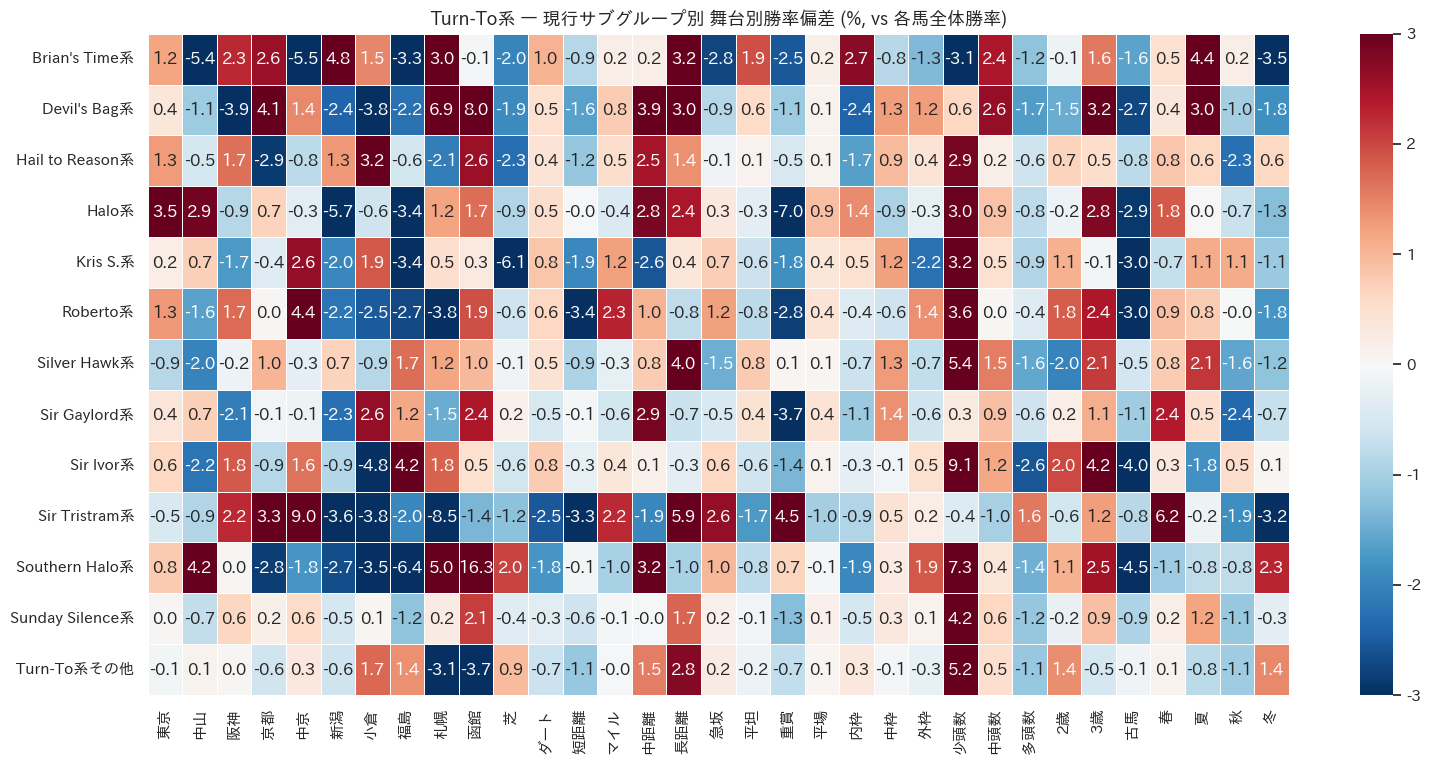

In [8]:
# 現行サブグループ × 条件別 平均偏差ヒートマップ
feat_valid2 = feat_valid.copy()
for col in cond_cols:
    feat_valid2[col] = X_raw.loc[feat_valid2.index, col]  # 元の偏差値を使用

heatmap_data = feat_valid2.groupby('sub_group_label')[cond_cols].mean()

# 列名を短く整形
col_labels = {
    'win_s_芝': '芝', 'win_s_ダート': 'ダート',
    'win_d_短距離': '短距離', 'win_d_マイル': 'マイル',
    'win_d_中距離': '中距離', 'win_d_長距離': '長距離',
    'win_steep': '急坂', 'win_flat': '平坦',
    'win_graded': '重賞', 'win_maiden': '平場',
}
for v in MAJOR_VENUES:
    col_labels[f'win_v_{v}'] = v

# 枠番・頭数・馬齢・季節ラベル
for grp in ['内枠', '中枠', '外枠']:
    col_labels[f'win_b_{grp}'] = grp
for grp in ['少頭数', '中頭数', '多頭数']:
    col_labels[f'win_f_{grp}'] = grp
for grp in ['2歳', '3歳', '古馬']:
    col_labels[f'win_a_{grp}'] = grp
for grp in ['春', '夏', '秋', '冬']:
    col_labels[f'win_season_{grp}'] = grp

heatmap_data = heatmap_data.rename(columns=col_labels)

fig, ax = plt.subplots(figsize=(16, max(4, len(heatmap_data) * 0.6)))
sns.heatmap(
    heatmap_data * 100,  # % 表示
    cmap='RdBu_r', center=0, annot=True, fmt='.1f',
    linewidths=.4, ax=ax, vmin=-3, vmax=3
)
ax.set_title(f'{TARGET_GROUP} — 現行サブグループ別 舞台別勝率偏差 (%, vs 各馬全体勝率)', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 7. PCA による次元削減

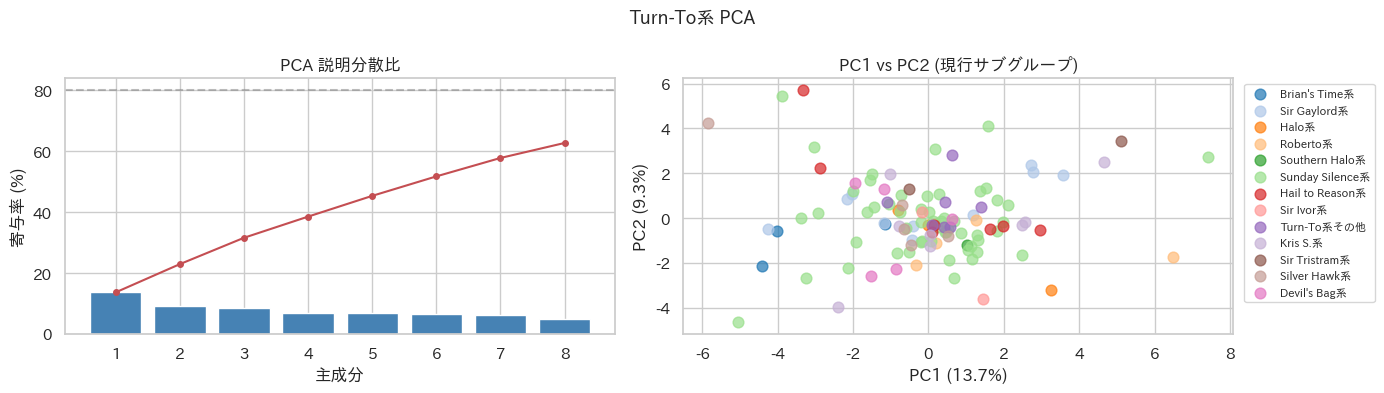

PC1 主要寄与特徴量 (上位5):
急坂    0.422416
平坦    0.412447
夏     0.311694
中山    0.299861
新潟    0.288605
dtype: float64

PC2 主要寄与特徴量 (上位5):
古馬     0.419880
秋      0.316340
2歳     0.288945
長距離    0.287566
中枠     0.274909
dtype: float64


In [9]:
# PCA
pca = PCA(n_components=min(8, X_scaled.shape[1]))
X_pca = pca.fit_transform(X_scaled)

# 説明分散比
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ev = pca.explained_variance_ratio_
axes[0].bar(range(1, len(ev)+1), ev * 100, color='steelblue')
axes[0].plot(range(1, len(ev)+1), np.cumsum(ev) * 100, 'r-o', markersize=4)
axes[0].axhline(80, color='gray', linestyle='--', alpha=.5)
axes[0].set_xlabel('主成分')
axes[0].set_ylabel('寄与率 (%)')
axes[0].set_title('PCA 説明分散比')

# PC1 vs PC2 散布図（現行サブグループで色分け）
subgroups = feat_valid['sub_group_label'].unique()
palette   = sns.color_palette('tab20', len(subgroups))
sg_color  = dict(zip(subgroups, palette))

for sg in subgroups:
    mask = feat_valid['sub_group_label'].values == sg
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    label=sg, color=sg_color[sg], alpha=.7, s=60)

axes[1].set_xlabel(f'PC1 ({ev[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
axes[1].set_title('PC1 vs PC2 (現行サブグループ)')
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.suptitle(f'{TARGET_GROUP} PCA', fontsize=13)
plt.tight_layout()
plt.show()

print('PC1 主要寄与特徴量 (上位5):')
loadings = pd.Series(pca.components_[0], index=X_valid.columns).abs().sort_values(ascending=False)
print(loadings.head(5).rename(col_labels))

print('\nPC2 主要寄与特徴量 (上位5):')
loadings2 = pd.Series(pca.components_[1], index=X_valid.columns).abs().sort_values(ascending=False)
print(loadings2.head(5).rename(col_labels))

## 8. 最適クラスタ数の探索（エルボー法 + シルエット係数）

クラスタ数探索中...
  k=2: Sil=0.083  CH=9.3  DB=3.054  Gap=1.323
  k=3: Sil=0.055  CH=7.3  DB=3.065  Gap=1.327
  k=4: Sil=0.119  CH=6.9  DB=2.313  Gap=1.346
  k=5: Sil=0.043  CH=6.2  DB=2.478  Gap=1.355
  k=6: Sil=0.155  CH=5.9  DB=1.881  Gap=1.363
  k=7: Sil=0.105  CH=5.8  DB=1.831  Gap=1.381
  k=8: Sil=0.101  CH=5.0  DB=1.643  Gap=1.366
  k=9: Sil=0.114  CH=5.3  DB=1.353  Gap=1.399
  k=10: Sil=0.103  CH=5.0  DB=1.320  Gap=1.399
  k=11: Sil=0.048  CH=5.4  DB=1.508  Gap=1.442

最適k の推定:
  シルエット係数:        k = 6
  Calinski-Harabasz:   k = 2
  Davies-Bouldin:      k = 10
  Gap Statistics:      k = 2

→ 多数決による推奨 k = 2


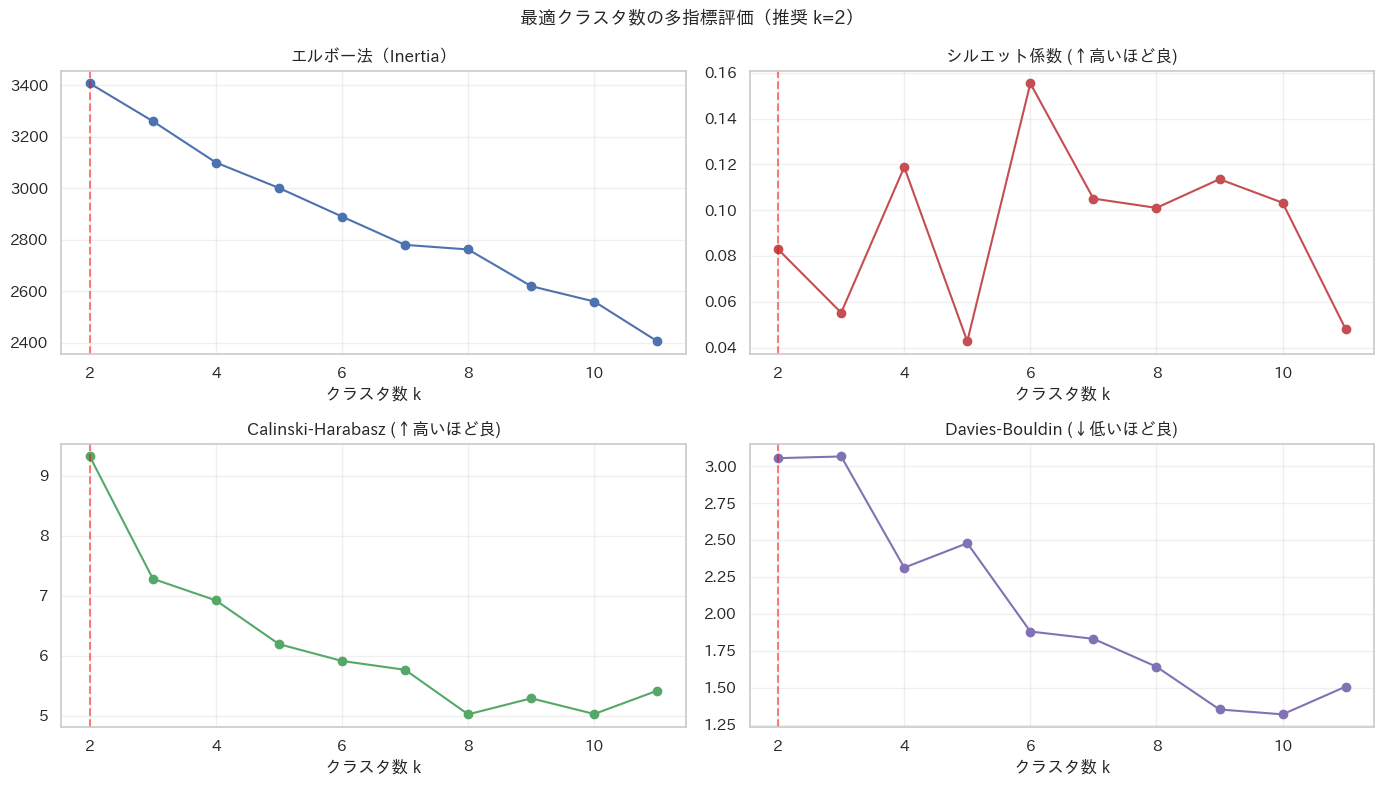

In [10]:
# ── 最適クラスタ数の多指標探索 ──────────────────────────────────────────────
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

K_RANGE = range(2, min(12, len(X_valid) // 3))

metrics = {'k':[], 'inertia':[], 'silhouette':[], 'calinski_harabasz':[], 'davies_bouldin':[]}

# Gap Statistics（ランダム参照分布との比較）
def gap_statistic(X, k, n_ref=10, random_state=42):
    rng = np.random.default_rng(random_state)
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    W_k = np.log(km.inertia_)
    ref_inertias = []
    for _ in range(n_ref):
        ref = rng.uniform(X.min(axis=0), X.max(axis=0), X.shape)
        ref_km = KMeans(n_clusters=k, random_state=42, n_init=5)
        ref_km.fit(ref)
        ref_inertias.append(np.log(ref_km.inertia_))
    gap = np.mean(ref_inertias) - W_k
    sk  = np.std(ref_inertias) * np.sqrt(1 + 1/n_ref)
    return gap, sk

print("クラスタ数探索中...")
gaps, sks = [], []
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    metrics['k'].append(k)
    metrics['inertia'].append(km.inertia_)
    metrics['silhouette'].append(silhouette_score(X_scaled, labels))
    metrics['calinski_harabasz'].append(calinski_harabasz_score(X_scaled, labels))
    metrics['davies_bouldin'].append(davies_bouldin_score(X_scaled, labels))
    gap, sk = gap_statistic(X_scaled, k)
    gaps.append(gap); sks.append(sk)
    print(f"  k={k}: Sil={metrics['silhouette'][-1]:.3f}  CH={metrics['calinski_harabasz'][-1]:.1f}  DB={metrics['davies_bouldin'][-1]:.3f}  Gap={gap:.3f}")

met_df = pd.DataFrame(metrics)

# Gap法による最適k（gap(k) >= gap(k+1) - sk+1 を満たす最小k）
best_gap_k = list(K_RANGE)[0]
for i in range(len(gaps)-1):
    if gaps[i] >= gaps[i+1] - sks[i+1]:
        best_gap_k = list(K_RANGE)[i]
        break

best_sil_k = met_df.loc[met_df['silhouette'].idxmax(), 'k']
best_ch_k  = met_df.loc[met_df['calinski_harabasz'].idxmax(), 'k']
best_db_k  = met_df.loc[met_df['davies_bouldin'].idxmin(), 'k']

print(f"\n最適k の推定:")
print(f"  シルエット係数:        k = {best_sil_k}")
print(f"  Calinski-Harabasz:   k = {best_ch_k}")
print(f"  Davies-Bouldin:      k = {best_db_k}")
print(f"  Gap Statistics:      k = {best_gap_k}")

# 多数決
from collections import Counter
votes = Counter([best_sil_k, best_ch_k, best_db_k, best_gap_k])
best_k = votes.most_common(1)[0][0]
print(f"\n→ 多数決による推奨 k = {best_k}")

# 可視化
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
ks = list(K_RANGE)

axes[0,0].plot(ks, metrics['inertia'], 'bo-'); axes[0,0].set_title('エルボー法（Inertia）'); axes[0,0].axvline(best_k, color='red', ls='--', alpha=.5)
axes[0,1].plot(ks, metrics['silhouette'], 'ro-'); axes[0,1].set_title('シルエット係数 (↑高いほど良)'); axes[0,1].axvline(best_k, color='red', ls='--', alpha=.5)
axes[1,0].plot(ks, metrics['calinski_harabasz'], 'go-'); axes[1,0].set_title('Calinski-Harabasz (↑高いほど良)'); axes[1,0].axvline(best_k, color='red', ls='--', alpha=.5)
axes[1,1].plot(ks, metrics['davies_bouldin'], 'mo-'); axes[1,1].set_title('Davies-Bouldin (↓低いほど良)'); axes[1,1].axvline(best_k, color='red', ls='--', alpha=.5)

for ax in axes.flat:
    ax.set_xlabel('クラスタ数 k')
    ax.grid(True, alpha=.3)

plt.suptitle(f'最適クラスタ数の多指標評価（推奨 k={best_k}）', fontsize=13)
plt.tight_layout()
plt.show()


## 9. アンサンブルクラスタリング（KMeans + Ward + 結果統合）

クラスタ数: 5  (統計推奨=2, フロア=5, 上限=11)
KMeans    : Silhouette=0.043  CH=6.2  DB=2.478
Ward      : Silhouette=0.253  CH=6.3  DB=1.758
Ensemble  : Silhouette=0.264  CH=6.4  DB=1.705

→ 最良手法: Ensemble (Silhouette=0.264)


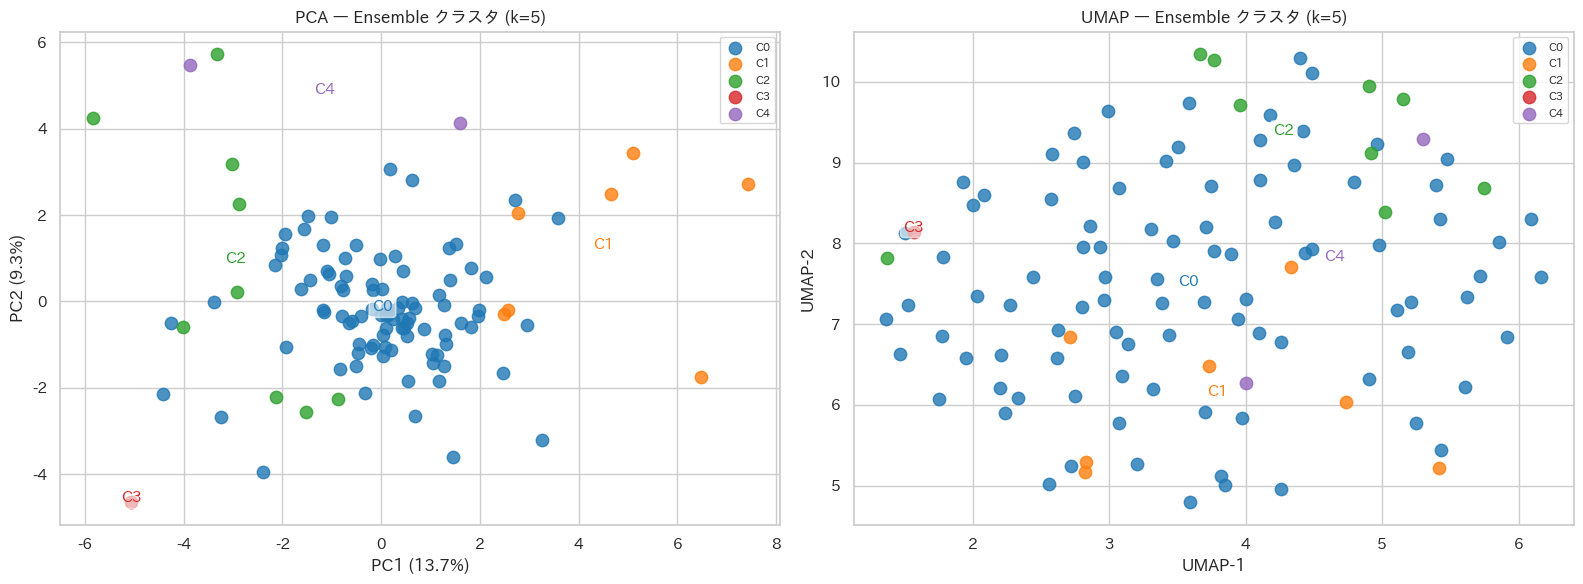

In [11]:
# ── グループ別 最小クラスタ数（納得感のある粒度を確保） ──────────────────────
#   各系統の頭数と系譜の多様性から設定。best_k が下回る場合はフロアを使用。
N_CLUSTERS_FLOOR_MAP = {
    'Turn-To系':         5,   # SS系/Sir Gaylord/HailToReason/Roberto 等 5系統
    'Northern Dancer系': 6,   # NijinskyⅡ/DanzigⅡ/Sadler's Wells 等 多様
    'Native Dancer系':   4,   # Mr.Prospector/Raise a Native 等
    'Nasrullah系':       4,   # Bold Ruler/Never Bend/Red God 等
    '非主流':            5,   # 多様な小系統を一定数に分割
}
N_CLUSTERS_FLOOR = N_CLUSTERS_FLOOR_MAP.get(TARGET_GROUP, 4)

# データ量に応じた上限: 1クラスタ当たり最低 10 頭を確保
N_CLUSTERS_CEIL = max(N_CLUSTERS_FLOOR, len(X_valid) // 10)

# 最終クラスタ数（統計最適 best_k よりフロアを優先）
N_CLUSTERS = max(best_k, N_CLUSTERS_FLOOR)
N_CLUSTERS = min(N_CLUSTERS, N_CLUSTERS_CEIL)   # 上限超えを防止

print(f"クラスタ数: {N_CLUSTERS}  (統計推奨={best_k}, フロア={N_CLUSTERS_FLOOR}, 上限={N_CLUSTERS_CEIL})")

# ── KMeans ────────────────────────────────────────────────────
km_final = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=20)
km_labels = km_final.fit_predict(X_scaled)

# ── Ward 階層クラスタリング ────────────────────────────────────
from sklearn.cluster import AgglomerativeClustering
ward = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward')
ward_labels = ward.fit_predict(X_scaled)

# ── アンサンブル: 類似度行列から合意クラスタを取得 ────────────────
# 同じクラスタに属する頻度を「合意行列」として構築
n = len(X_scaled)
consensus = np.zeros((n, n))
for labels in [km_labels, ward_labels]:
    for i in range(n):
        for j in range(n):
            if labels[i] == labels[j]:
                consensus[i, j] += 1
consensus /= 2  # 0〜1 に正規化

# 合意行列を距離行列として Ward クラスタリング
from sklearn.cluster import AgglomerativeClustering
dist_consensus = 1 - consensus
ensemble_clust = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='average', metric='precomputed')
ensemble_labels = ensemble_clust.fit_predict(dist_consensus)

# 品質比較
for name, labels in [('KMeans', km_labels), ('Ward', ward_labels), ('Ensemble', ensemble_labels)]:
    sil = silhouette_score(X_scaled, labels)
    ch  = calinski_harabasz_score(X_scaled, labels)
    db  = davies_bouldin_score(X_scaled, labels)
    print(f"{name:10s}: Silhouette={sil:.3f}  CH={ch:.1f}  DB={db:.3f}")

# 最良手法を選択（シルエット係数で判定）
scores = {
    'KMeans':   silhouette_score(X_scaled, km_labels),
    'Ward':     silhouette_score(X_scaled, ward_labels),
    'Ensemble': silhouette_score(X_scaled, ensemble_labels),
}
best_method = max(scores, key=scores.get)
print(f"\n→ 最良手法: {best_method} (Silhouette={scores[best_method]:.3f})")

cluster_labels_map = {'KMeans': km_labels, 'Ward': ward_labels, 'Ensemble': ensemble_labels}
cluster_labels = cluster_labels_map[best_method]
feat_valid['cluster'] = cluster_labels

# ── PCA + UMAP 散布図（クラスタで色分け）────────────────────────
import umap as umap_lib
reducer = umap_lib.UMAP(n_neighbors=10, min_dist=0.3, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

palette_k = sns.color_palette('tab10', N_CLUSTERS)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA 散布図
for k in range(N_CLUSTERS):
    mask = cluster_labels == k
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'C{k}', color=palette_k[k], alpha=.8, s=80)
    cx, cy = X_pca[mask, 0].mean(), X_pca[mask, 1].mean()
    axes[0].annotate(f'C{k}', (cx, cy), fontsize=11, fontweight='bold',
                     ha='center', color=palette_k[k],
                     bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=.6))
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title(f'PCA — {best_method} クラスタ (k={N_CLUSTERS})')
axes[0].legend(loc='best', fontsize=8)

# UMAP 散布図
for k in range(N_CLUSTERS):
    mask = cluster_labels == k
    axes[1].scatter(X_umap[mask, 0], X_umap[mask, 1], label=f'C{k}', color=palette_k[k], alpha=.8, s=80)
    cx, cy = X_umap[mask, 0].mean(), X_umap[mask, 1].mean()
    axes[1].annotate(f'C{k}', (cx, cy), fontsize=11, fontweight='bold',
                     ha='center', color=palette_k[k],
                     bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=.6))
axes[1].set_xlabel('UMAP-1'); axes[1].set_ylabel('UMAP-2')
axes[1].set_title(f'UMAP — {best_method} クラスタ (k={N_CLUSTERS})')
axes[1].legend(loc='best', fontsize=8)

plt.tight_layout(); plt.show()


## 10. クラスタプロファイル（各クラスタの特徴）

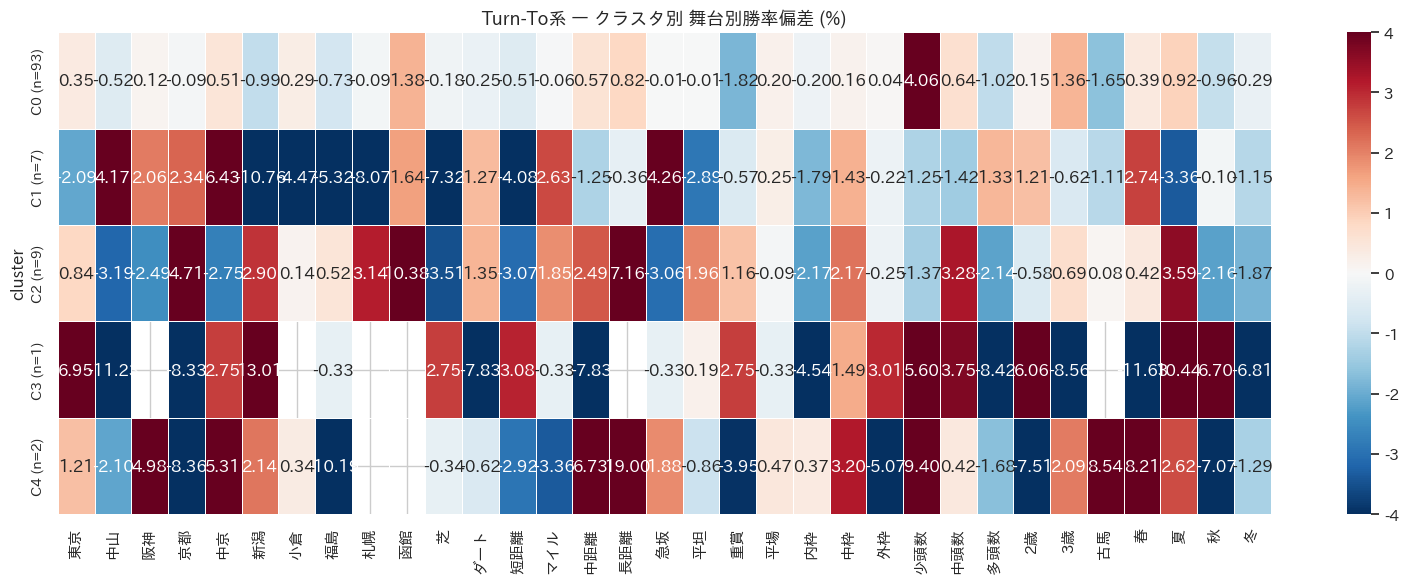

In [12]:
# クラスタ × 条件別 平均偏差ヒートマップ
feat_valid_prof = feat_valid.copy()
for col in cond_cols:
    feat_valid_prof[col] = X_raw.loc[feat_valid_prof.index, col]

profile = feat_valid_prof.groupby('cluster')[cond_cols].mean().rename(columns=col_labels)
profile_n = feat_valid_prof.groupby('cluster').size().rename('n')

fig, ax = plt.subplots(figsize=(16, N_CLUSTERS * 0.8 + 2))
sns.heatmap(
    profile * 100,
    cmap='RdBu_r', center=0, annot=True, fmt='.2f',
    linewidths=.4, ax=ax, vmin=-4, vmax=4
)
ax.set_yticklabels([f'C{k} (n={profile_n.get(k,0)})' for k in profile.index], fontsize=10)
ax.set_title(f'{TARGET_GROUP} — クラスタ別 舞台別勝率偏差 (%)', fontsize=13)
plt.tight_layout()
plt.show()

## 11. クラスタ別 種牡馬一覧

In [13]:
for k in range(N_CLUSTERS):
    members = feat_valid[feat_valid['cluster'] == k][['stallion_name','sub_group_label','n_horses']]\
              .sort_values('n_horses', ascending=False)
    print(f'\n=== Cluster {k}  ({len(members)}頭) ===')
    
    # サブグループ分布
    sg_dist = members['sub_group_label'].value_counts()
    print('  構成サブグループ:', sg_dist.to_dict())
    
    # 上位20頭
    display_cols = ['stallion_name', 'sub_group_label', 'n_horses']
    print(members.head(20).to_string(index=False))


=== Cluster 0  (93頭) ===
  構成サブグループ: {'Sunday Silence系': 47, 'Sir Gaylord系': 9, 'Turn-To系その他': 7, 'Kris S.系': 5, 'Hail to Reason系': 5, 'Silver Hawk系': 4, 'Roberto系': 4, 'Halo系': 3, "Devil's Bag系": 3, 'Sir Ivor系': 2, "Brian's Time系": 2, 'Southern Halo系': 1, 'Sir Tristram系': 1}
 stallion_name sub_group_label  n_horses
       Turn-to     Turn-To系その他      9763
Hail to Reason Hail to Reason系      8736
     サンデーサイレンス Sunday Silence系      5587
          Halo           Halo系      4968
     ディープインパクト Sunday Silence系      3296
       Roberto        Roberto系      2180
   Sir Gaylord    Sir Gaylord系      1096
        ハーツクライ Sunday Silence系      1004
   Bold Reason Hail to Reason系       942
     シンボリクリスエス        Kris S.系       931
       ステイゴールド Sunday Silence系       882
         フジキセキ Sunday Silence系       882
      Sir Ivor       Sir Ivor系       868
     スクリーンヒーロー    Silver Hawk系       709
       エピファネイア        Kris S.系       611
           キズナ Sunday Silence系       601
       ダイワメジャー Sunday Sil

## 12. 階層クラスタリング（デンドログラム）

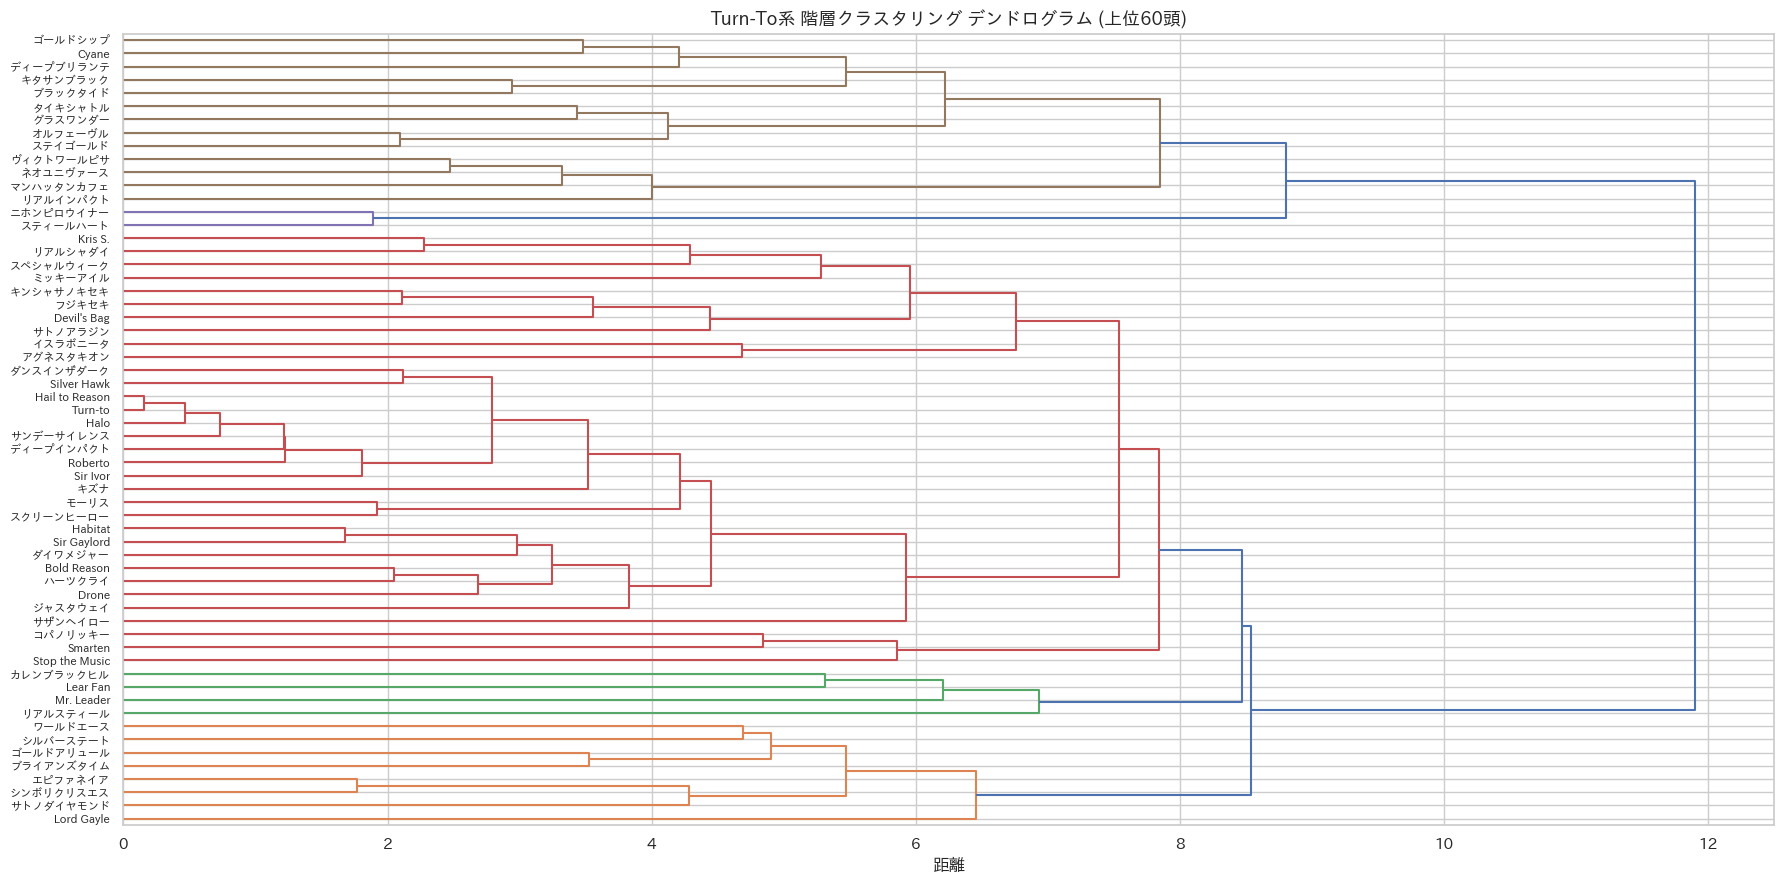

In [14]:
# 出走馬数上位N頭に絞ってデンドログラムを描画（可読性のため）
TOP_N_DENDRO = 60

top_idx = feat_valid.nlargest(TOP_N_DENDRO, 'n_horses').index
X_top   = X_scaled[[list(feat_valid.index).index(i) for i in top_idx]]
labels_top = feat_valid.loc[top_idx, 'stallion_name'].tolist()

Z = linkage(X_top, method='ward')

fig, ax = plt.subplots(figsize=(18, 9))
dendrogram(
    Z, labels=labels_top, orientation='right',
    leaf_font_size=8, ax=ax,
    color_threshold=Z[-N_CLUSTERS+1, 2]  # k クラスタに対応するカット高さ
)
ax.set_title(f'{TARGET_GROUP} 階層クラスタリング デンドログラム (上位{TOP_N_DENDRO}頭)', fontsize=13)
ax.set_xlabel('距離')
plt.tight_layout()
plt.show()

## 13. 個別種牡馬の条件別プロファイル表示

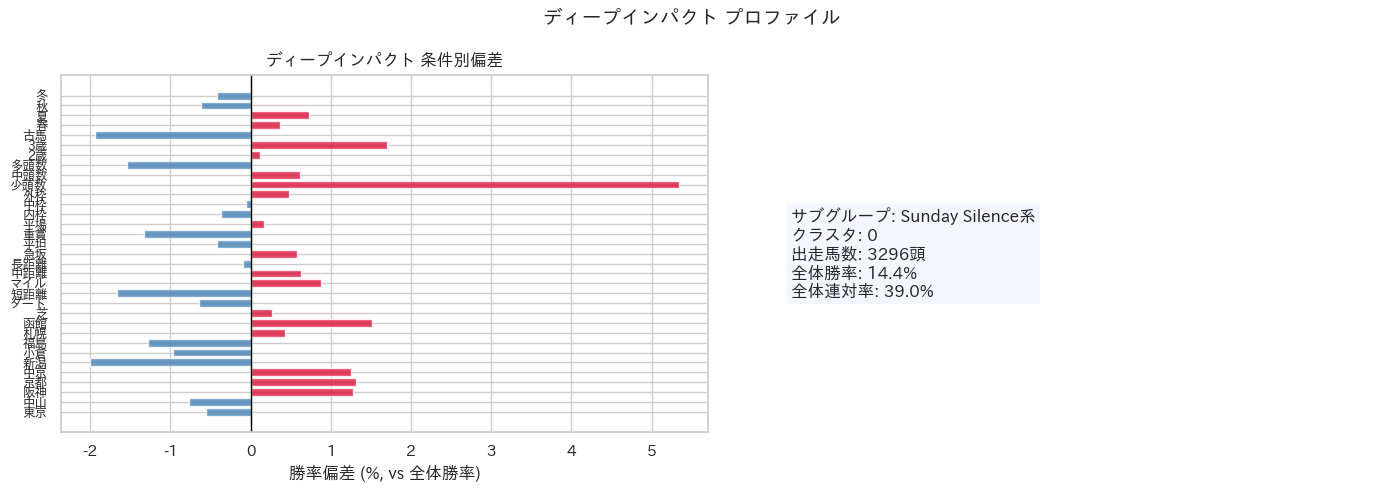

In [15]:
def plot_stallion_profile(stallion_name_query: str):
    """特定の種牡馬の条件別勝率偏差をレーダーチャートで表示。"""
    row = feat_valid[feat_valid['stallion_name'].str.contains(stallion_name_query, na=False)]
    if row.empty:
        print(f'種牡馬 "{stallion_name_query}" が見つかりません')
        print('候補:', feat_valid['stallion_name'].dropna().str[:10].unique()[:20])
        return
    
    row = row.iloc[0]
    sid = row.name
    vals = X_raw.loc[sid, cond_cols].rename(col_labels) * 100  # % 変換
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # バーチャート
    colors = ['crimson' if v > 0 else 'steelblue' for v in vals.values]
    axes[0].barh(range(len(vals)), vals.values, color=colors, alpha=.8)
    axes[0].set_yticks(range(len(vals)))
    axes[0].set_yticklabels(vals.index, fontsize=9)
    axes[0].axvline(0, color='black', linewidth=1)
    axes[0].set_xlabel('勝率偏差 (%, vs 全体勝率)')
    axes[0].set_title(f'{row["stallion_name"]} 条件別偏差')
    
    # 実績サマリ
    info_text = (
        f'サブグループ: {row.get("sub_group_label", "?")}\n'
        f'クラスタ: {row.get("cluster", "?")}\n'
        f'出走馬数: {int(row.get("n_horses", 0))}頭\n'
        f'全体勝率: {feat_df.loc[sid, "win_rate_total"]*100:.1f}%\n'
        f'全体連対率: {feat_df.loc[sid, "place_rate_total"]*100:.1f}%'
    )
    axes[1].text(0.1, 0.5, info_text, transform=axes[1].transAxes,
                 fontsize=12, va='center',
                 bbox=dict(boxstyle='round', facecolor='#f0f4ff', alpha=.8))
    axes[1].axis('off')
    
    plt.suptitle(f'{stallion_name_query} プロファイル', fontsize=14)
    plt.tight_layout()
    plt.show()

# 例: ディープインパクト、キングカメハメハ などを試す
plot_stallion_profile('ディープインパクト')

## 14. クラスタ別 代表種牡馬プロファイル比較

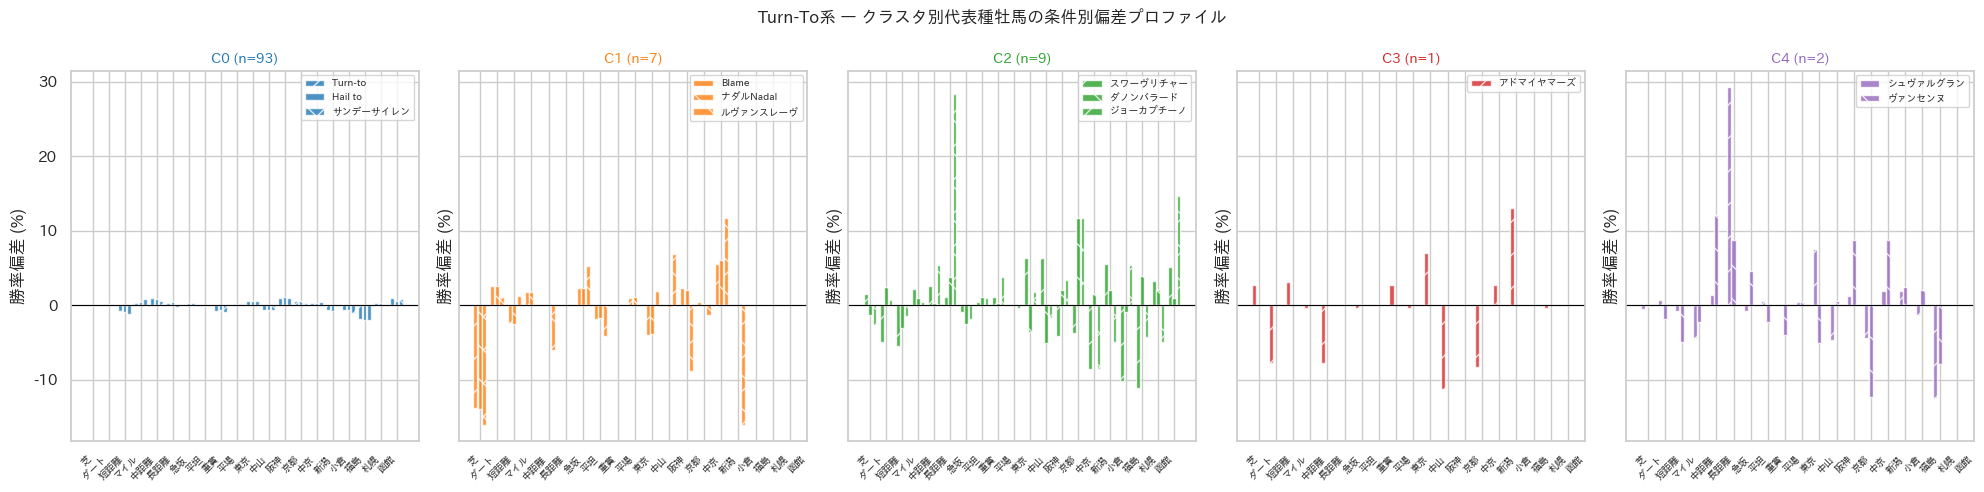

In [16]:
# 各クラスタの代表（n_horses 最大）をレーダーチャート的に比較
TOP_PER_CLUSTER = 3  # 各クラスタから上位N頭

fig, axes = plt.subplots(1, N_CLUSTERS, figsize=(N_CLUSTERS * 4, 5), sharey=True)
if N_CLUSTERS == 1:
    axes = [axes]

cond_labels_short = [
    '芝', 'ダート', '短距離', 'マイル', '中距離', '長距離',
    '急坂', '平坦', '重賞', '平場'
] + MAJOR_VENUES
selected_cols = [
    'win_s_芝', 'win_s_ダート', 'win_d_短距離', 'win_d_マイル',
    'win_d_中距離', 'win_d_長距離', 'win_steep', 'win_flat',
    'win_graded', 'win_maiden'
] + [f'win_v_{v}' for v in MAJOR_VENUES]
selected_cols = [c for c in selected_cols if c in cond_cols]
sel_labels    = [col_labels.get(c, c) for c in selected_cols]

for k, ax in enumerate(axes):
    cluster_df = feat_valid[feat_valid['cluster'] == k]
    top_members = cluster_df.nlargest(TOP_PER_CLUSTER, 'n_horses')
    
    x = np.arange(len(selected_cols))
    width = 0.8 / TOP_PER_CLUSTER
    
    for i, (sid, mrow) in enumerate(top_members.iterrows()):
        vals = X_raw.loc[sid, selected_cols].values * 100
        ax.bar(x + i * width, vals, width=width * 0.9,
               label=str(mrow['stallion_name'])[:8], alpha=.8,
               color=palette_k[k], hatch=['/', '\\', 'x'][i % 3])
    
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x + width)
    ax.set_xticklabels(sel_labels, rotation=45, ha='right', fontsize=7)
    ax.set_title(f'C{k} (n={len(cluster_df)})', color=palette_k[k], fontsize=10)
    ax.set_ylabel('勝率偏差 (%)')
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle(f'{TARGET_GROUP} — クラスタ別代表種牡馬の条件別偏差プロファイル', fontsize=12)
plt.tight_layout()
plt.show()

## 15. 現行サブグループ vs データ駆動クラスタ の比較クロス表

Turn-To系: 現行サブグループ × データ駆動クラスタ クロス表


cluster,C0,C1,C2,C3,C4,All
sub_group_label,,,,,,
Brian's Time系,2,0,1,0,0,3
Devil's Bag系,3,0,2,0,0,5
Hail to Reason系,5,0,2,0,0,7
Halo系,3,0,0,0,0,3
Kris S.系,5,3,0,0,0,8
Roberto系,4,1,0,0,0,5
Silver Hawk系,4,0,1,0,0,5
Sir Gaylord系,9,1,0,0,0,10
Sir Ivor系,2,0,0,0,0,2


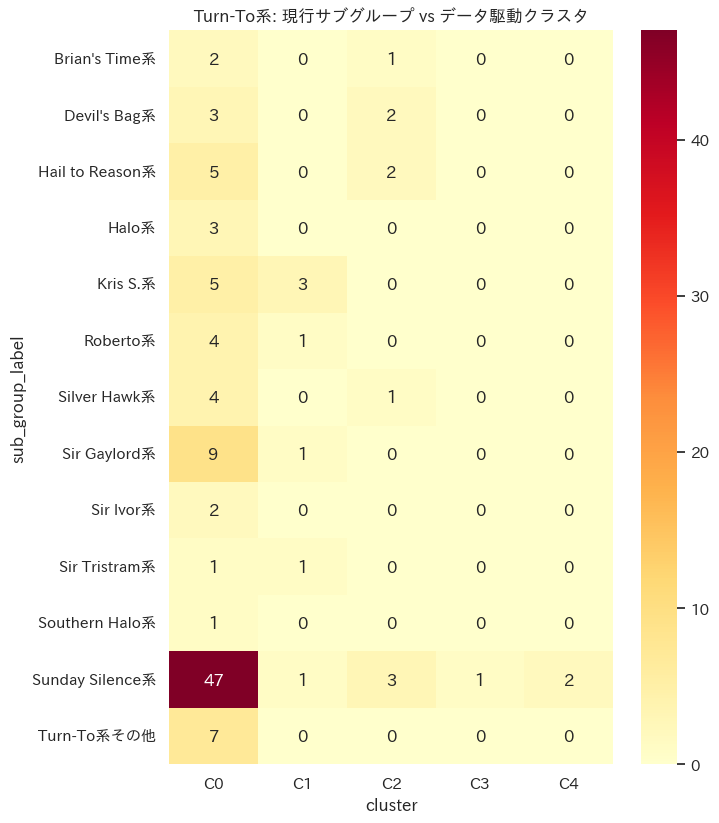

In [17]:
cross = pd.crosstab(
    feat_valid['sub_group_label'],
    feat_valid['cluster'].apply(lambda k: f'C{k}'),
    margins=True
)
print(f'{TARGET_GROUP}: 現行サブグループ × データ駆動クラスタ クロス表')
display(cross)

# ヒートマップ
fig, ax = plt.subplots(figsize=(max(6, N_CLUSTERS * 1.5), max(4, len(cross) * 0.6)))
sns.heatmap(
    cross.iloc[:-1, :-1],  # margins 除外
    annot=True, fmt='d', cmap='YlOrRd', ax=ax
)
ax.set_title(f'{TARGET_GROUP}: 現行サブグループ vs データ駆動クラスタ', fontsize=12)
plt.tight_layout()
plt.show()

## 16. ★ グループ変更: 別の主流血統を分析

以下のセルで `TARGET_GROUP` を変更して **セル 3 (「3. 対象グループ...」) から再実行** してください。

```python
TARGET_GROUP = 'Northern Dancer系'  # ← ここを変更
# 'Turn-To系' / 'Northern Dancer系' / 'Native Dancer系' / 'Nasrullah系'
```

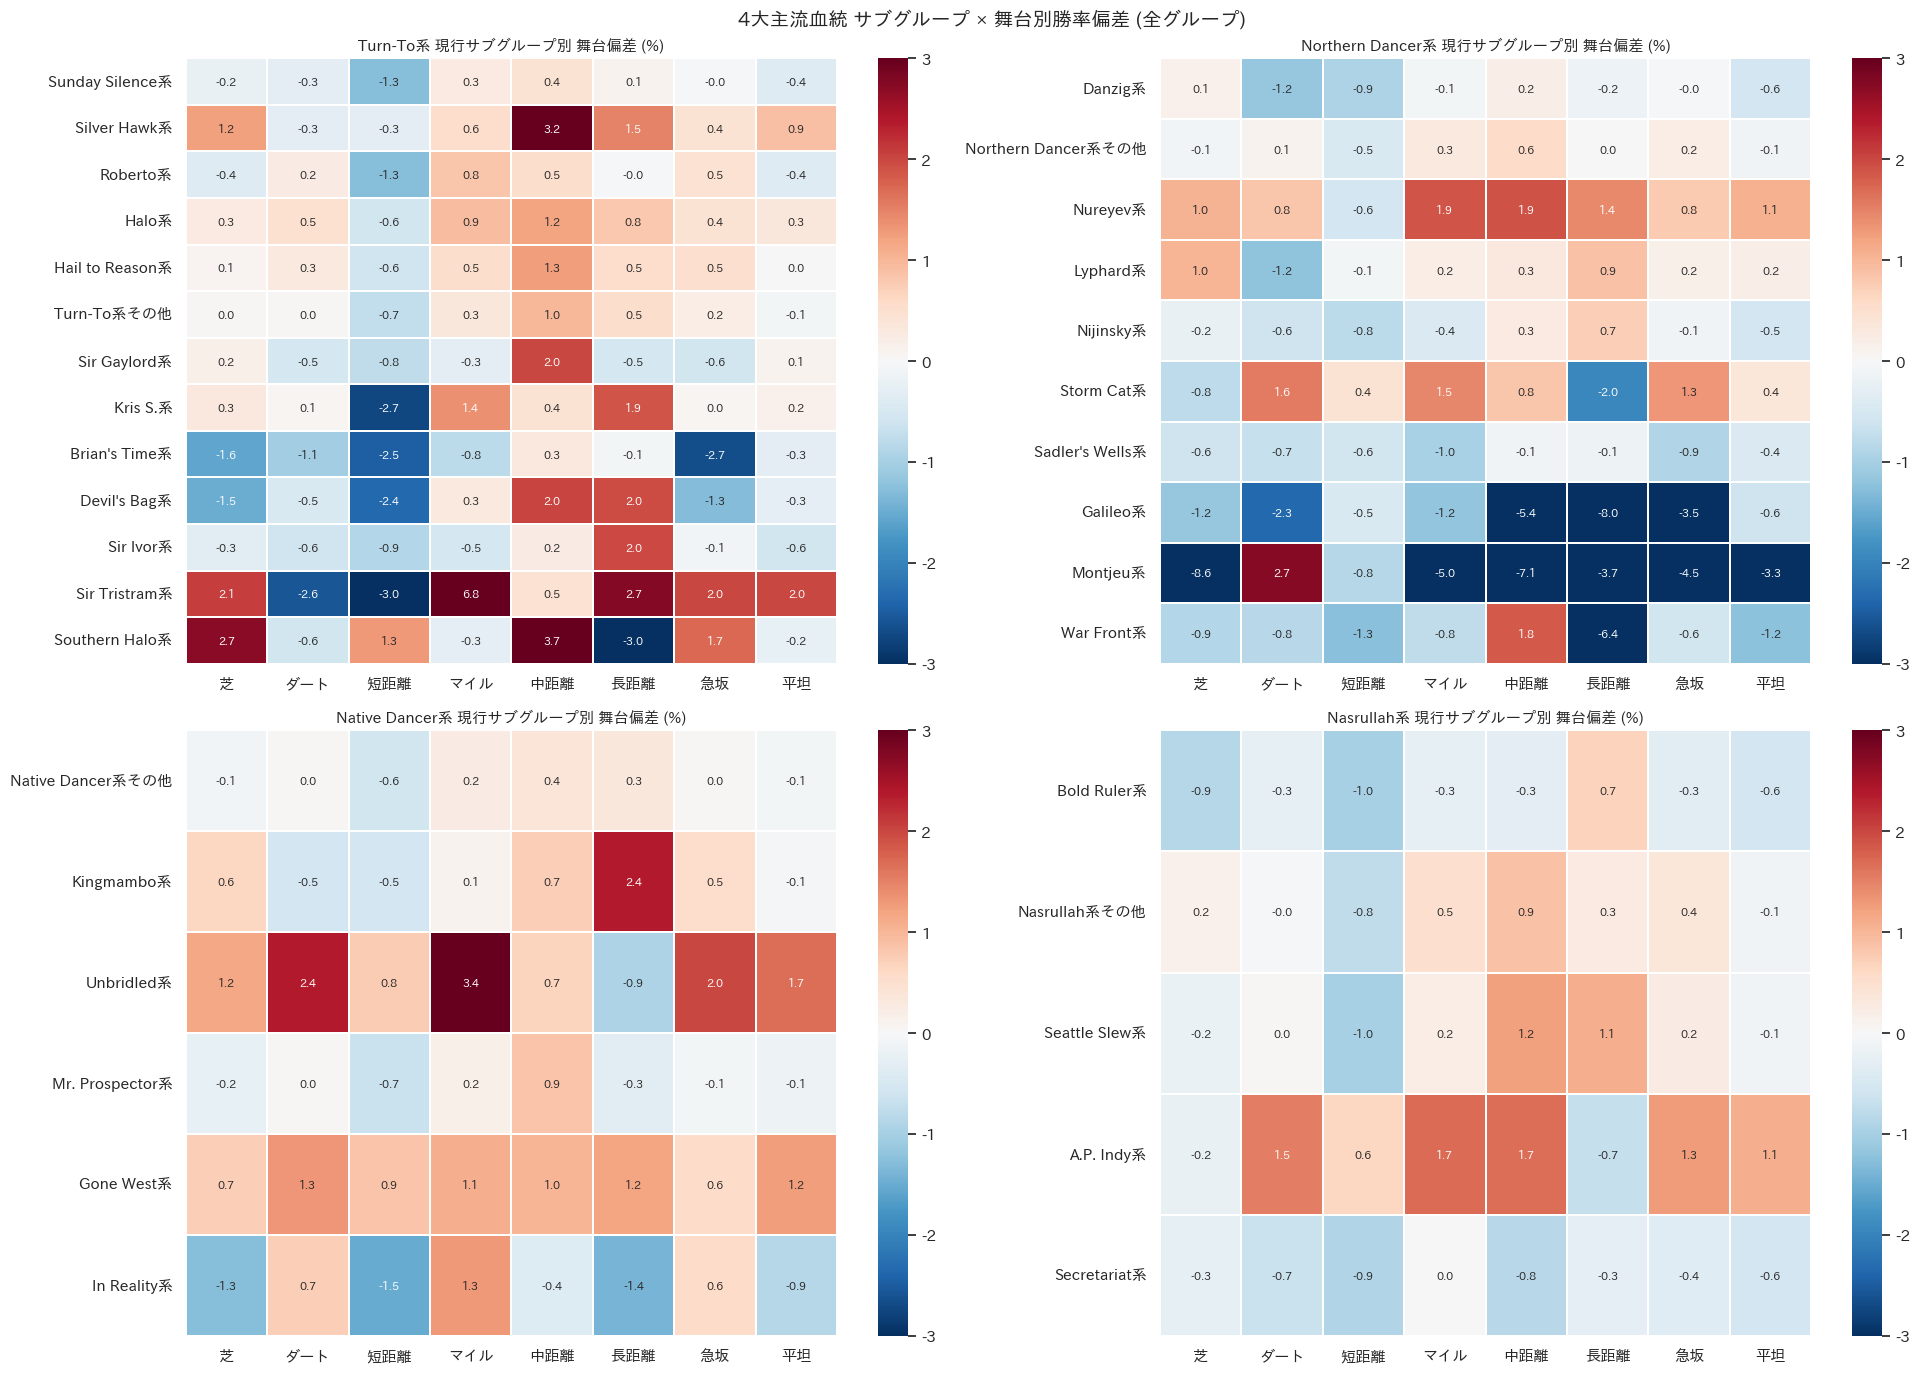

In [18]:
# ── 簡易まとめ: 全グループの舞台別偏差ヒートマップ一括表示 ──
# ※ 実行に時間がかかる場合があります

ALL_GROUPS = ['Turn-To系', 'Northern Dancer系', 'Native Dancer系', 'Nasrullah系']

def build_group_profile(group_name):
    """特定グループの種牡馬 × 条件別 平均勝率偏差を計算。"""
    tlin = lin[lin['main_group_name'] == group_name]
    mc = cats.merge(tlin[['stallion_id','sub_group_label']], on='stallion_id', how='inner')
    rf2 = race.merge(mc[['horse_id','stallion_id','sub_group_label']], on='horse_id', how='inner')
    rf2['dist_cat'] = pd.cut(rf2['distance'], bins=DIST_BINS, labels=DIST_LABELS)
    rf2['is_steep'] = rf2['venue'].isin(STEEP_VENUES)
    
    # サブグループ × 条件別 勝率
    conds = {
        '芝':    rf2['surface'] == '芝',
        'ダート': rf2['surface'] == 'ダート',
        '短距離': rf2['dist_cat'] == '短距離',
        'マイル': rf2['dist_cat'] == 'マイル',
        '中距離': rf2['dist_cat'] == '中距離',
        '長距離': rf2['dist_cat'] == '長距離',
        '急坂':   rf2['is_steep'],
        '平坦':   ~rf2['is_steep'],
    }
    rows = {}
    baseline_wr = (rf2['win'].sum() / rf2['valid'].sum()) if rf2['valid'].sum() > 0 else 0.0
    for sg in tlin['sub_group_label'].unique():
        sg_mask = rf2['sub_group_label'] == sg
        row = {}
        for cname, mask in conds.items():
            sub = rf2[sg_mask & mask]
            n = sub['valid'].sum()
            row[cname] = (sub['win'].sum() / n - baseline_wr) if n >= MIN_COND_N else np.nan
        rows[sg] = row
    return pd.DataFrame(rows).T

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
for ax, gname in zip(axes.flat, ALL_GROUPS):
    prof = build_group_profile(gname)
    if prof.empty:
        ax.set_title(f'{gname} (データなし)')
        continue
    sns.heatmap(prof * 100, cmap='RdBu_r', center=0, annot=True, fmt='.1f',
                vmin=-3, vmax=3, ax=ax, linewidths=.3, annot_kws={'size': 8})
    ax.set_title(f'{gname} 現行サブグループ別 舞台偏差 (%)', fontsize=11)

plt.suptitle('4大主流血統 サブグループ × 舞台別勝率偏差 (全グループ)', fontsize=14)
plt.tight_layout()
plt.show()

## 17. Sunday Silence系 単独深掘り分析
Turn-To系内最大サブグループ（54頭）を単独で再クラスタリングし、内部構造を詳細に分析する。

In [ ]:
# ── Sunday Silence系単独抽出 ────────────────────────────────────────────
SS_GROUP = 'Sunday Silence系'
ss_df = feat_valid[feat_valid['sub_group_label'] == SS_GROUP].copy()
print(f"{SS_GROUP}: {len(ss_df)} 頭")
if len(ss_df) < 6:
    print("頭数不足 — スキップ")
else:
    ss_ids   = ss_df.index
    ss_X_raw = X_raw.loc[ss_ids, cond_cols]

    # NaN 補完（列中央値）
    ss_X_imp = ss_X_raw.apply(lambda col: col.fillna(col.median()))
    # 欠損全列は 0 補完
    ss_X_imp = ss_X_imp.fillna(0)

    ss_scaler = StandardScaler()
    ss_X_sc   = ss_scaler.fit_transform(ss_X_imp)

    ss_pca = PCA(n_components=min(6, ss_X_sc.shape[0]-1, ss_X_sc.shape[1]))
    ss_X_pca = ss_pca.fit_transform(ss_X_sc)
    print(f"PCA 累積寄与率 (PC1-4): {ss_pca.explained_variance_ratio_[:4].cumsum()}")

    # 最適 k の探索
    SS_K_RANGE = range(2, min(7, len(ss_df) // 2))
    ss_sils, ss_chs, ss_dbs = [], [], []
    for k in SS_K_RANGE:
        lbl = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(ss_X_sc)
        ss_sils.append(silhouette_score(ss_X_sc, lbl))
        ss_chs.append(calinski_harabasz_score(ss_X_sc, lbl))
        ss_dbs.append(davies_bouldin_score(ss_X_sc, lbl))

    ss_best_k_sil = list(SS_K_RANGE)[np.argmax(ss_sils)]
    ss_best_k_ch  = list(SS_K_RANGE)[np.argmax(ss_chs)]
    ss_best_k_db  = list(SS_K_RANGE)[np.argmin(ss_dbs)]
    from collections import Counter as C2
    ss_best_k_vote = C2([ss_best_k_sil, ss_best_k_ch, ss_best_k_db]).most_common(1)[0][0]
    # Sunday Silence系はサブライン多様（SS/ディープ/ハーツ/キタサン等）→ 最低 4 グループ確保
    SS_FLOOR = 4
    ss_best_k = max(ss_best_k_vote, SS_FLOOR)
    ss_best_k = min(ss_best_k, len(ss_df) // 8)  # 1クラスタ最低8頭
    ss_best_k = max(ss_best_k, 2)  # 最低2
    print(f"Sunday Silence系 k: {ss_best_k}  (統計推奨={ss_best_k_vote}, フロア={SS_FLOOR})")

    # クラスタリング
    ss_km = KMeans(n_clusters=ss_best_k, random_state=42, n_init=20)
    ss_labels = ss_km.fit_predict(ss_X_sc)

    # ── マイクロクラスタ（3頭未満）を外れ値として除外し再クラスタリング ──
    SS_MIN_CLUSTER = 3
    micro_mask = np.array([False] * len(ss_labels))
    for _k in range(ss_best_k):
        if (ss_labels == _k).sum() < SS_MIN_CLUSTER:
            micro_mask |= (ss_labels == _k)

    if micro_mask.sum() > 0:
        outlier_names = ss_df.iloc[micro_mask]['stallion_name'].tolist()
        print(f"  外れ値 ({micro_mask.sum()}頭) を除外: {outlier_names}")
        ss_X_sc_clean   = ss_X_sc[~micro_mask]
        ss_X_pca_clean  = ss_X_pca[~micro_mask]
        ss_df_clean     = ss_df.iloc[~micro_mask].copy()
        # 有効クラスタ数を再確定（縮小）
        ss_best_k_clean = min(ss_best_k, len(ss_X_sc_clean) // SS_MIN_CLUSTER)
        ss_best_k_clean = max(ss_best_k_clean, 2)
        ss_km2     = KMeans(n_clusters=ss_best_k_clean, random_state=42, n_init=20)
        ss_labels2 = ss_km2.fit_predict(ss_X_sc_clean)
        # 外れ値除外後のデータに統一（labels / X / df のサイズを揃える）
        ss_labels = ss_labels2           # 53要素 (clean のみ)
        ss_X_sc   = ss_X_sc_clean        # 53行
        ss_X_pca  = ss_X_pca_clean       # 53行
        ss_df     = ss_df_clean          # 53行
        ss_best_k = ss_best_k_clean
        print(f"  再クラスタリング k={ss_best_k} ({len(ss_df)}頭)")
    else:
        print(f"  マイクロクラスタなし (全 {len(ss_labels)}頭 使用)")

    ss_df['cluster_ss'] = ss_labels  # labels と df は同サイズが保証済み

    # UMAP（外れ値除外後の ss_X_sc に合わせて再計算）
    ss_reducer = umap_lib.UMAP(n_neighbors=min(8, len(ss_X_sc)-1), min_dist=0.3, random_state=42)
    ss_X_umap = ss_reducer.fit_transform(ss_X_sc)

    # 散布図
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    pal = sns.color_palette('Set2', ss_best_k)
    for k in range(ss_best_k):
        mask = ss_labels == k
        axes[0].scatter(ss_X_pca[mask, 0], ss_X_pca[mask, 1], color=pal[k], alpha=.85, s=90, label=f'C{k}')
        cx, cy = ss_X_pca[mask, 0].mean(), ss_X_pca[mask, 1].mean()
        axes[0].annotate(f'C{k}', (cx, cy), fontsize=12, fontweight='bold', color=pal[k],
                         ha='center', bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=.7))
        for idx, (pid, prow) in enumerate(ss_df[mask].iterrows()):
            axes[0].annotate(str(prow['stallion_name'])[:8], 
                             (ss_X_pca[mask, 0][idx], ss_X_pca[mask, 1][idx]),
                             fontsize=6, ha='left', va='bottom', alpha=.7)
        axes[1].scatter(ss_X_umap[mask, 0], ss_X_umap[mask, 1], color=pal[k], alpha=.85, s=90, label=f'C{k}')
        cx, cy = ss_X_umap[mask, 0].mean(), ss_X_umap[mask, 1].mean()
        axes[1].annotate(f'C{k}', (cx, cy), fontsize=12, fontweight='bold', color=pal[k],
                         ha='center', bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=.7))
    axes[0].set_title(f'{SS_GROUP} PCA クラスタ (k={ss_best_k})'); axes[0].legend()
    axes[1].set_title(f'{SS_GROUP} UMAP クラスタ (k={ss_best_k})'); axes[1].legend()
    plt.tight_layout(); plt.show()

    # クラスタ別ヒートマップ
    ss_profile = ss_df.groupby('cluster_ss')[cond_cols].mean()
    ss_overall = X_raw.loc[ss_ids, cond_cols].mean()
    ss_profile_dev = ss_profile.subtract(ss_overall)
    ss_profile_dev_r = ss_profile_dev.rename(columns=col_labels)
    fig, ax = plt.subplots(figsize=(16, ss_best_k * 0.9 + 2))
    sns.heatmap(ss_profile_dev_r * 100, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
                linewidths=.4, ax=ax, vmin=-4, vmax=4)
    ax.set_title(f'{SS_GROUP} クラスタ別 舞台別勝率偏差 (%)', fontsize=13)
    plt.tight_layout(); plt.show()

    # クラスタ別メンバー一覧
    for k in range(ss_best_k):
        members = ss_df[ss_df['cluster_ss'] == k].nlargest(8, 'n_horses')
        print(f"\n=== Sunday Silence C{k} ({(ss_labels==k).sum()}頭) ===")
        print(members[['stallion_name', 'n_horses']].to_string(index=False))


## 18. 非主流血統のグルーピング
4大主流に属さない「非主流」種牡馬を対象に同様のクラスタリングを実施。出走馬数が多い種牡馬に絞り、主流血統との相対特性を探る。

In [ ]:
# ── 非主流血統の構築 ────────────────────────────────────────────────────────
# gen=1, cat=1 に絞ることで「現役種牡馬の直接の父」としての傾向のみを分析
# （古典的祖先馬 Nearco/Pharos 等が混在するのを防ぐ）
NM_MIN_HORSES = 30   # 直接の父に絞ると母数が減るため閾値を緩める

print("非主流血統のデータ構築中...")
nm_lin = lin[lin['main_group_name'] == '非主流'].copy()

# ★ 直接の父のみ: cat=1（父系因子）かつ gen=1（1世代 = 直接の父）
cats_direct = cats[(cats['cat'] == 1) & (cats['gen'] == 1)].copy()
nm_cats = cats_direct.merge(nm_lin[['stallion_id']], on='stallion_id', how='inner')
nm_rf = race.merge(nm_cats[['horse_id', 'stallion_id']], on='horse_id', how='inner')
print(f"  直接の父フィルタ: {len(cats_direct):,} レコード（全 {len(cats):,} 件中）")

# 必要なカラムを追加
nm_rf = nm_rf.copy()
nm_rf['dist_cat'] = pd.cut(nm_rf['distance'], bins=DIST_BINS, labels=DIST_LABELS)
nm_rf['is_steep'] = nm_rf['venue'].isin(STEEP_VENUES)
nm_rf['is_heavy'] = nm_rf['track_condition'].isin(['重', '不良'])
nm_rf['stallion_id_str'] = nm_rf['stallion_id'].astype(str)
nm_rf['horse_id_str']    = nm_rf['horse_id'].astype(str)

nm_horse_cnt = nm_rf.groupby('stallion_id_str')['horse_id_str'].nunique()
nm_valid = nm_horse_cnt[nm_horse_cnt >= NM_MIN_HORSES].index
nm_rf2 = nm_rf[nm_rf['stallion_id_str'].isin(nm_valid)].copy()
print(f"非主流 種牡馬数（>={NM_MIN_HORSES}頭）: {len(nm_valid)}")

# 特徴量構築（共通 compute_stat を流用）
nm_features = {}

nm_base = nm_rf2.groupby('stallion_id_str').apply(compute_stat).unstack()
nm_features['win_rate_total']   = nm_base['win_rate']
nm_features['place_rate_total'] = nm_base['place_rate']
nm_features['n_total']          = nm_base['n']

for v in MAJOR_VENUES:
    sub = nm_rf2[nm_rf2['venue'] == v].groupby('stallion_id_str').apply(compute_stat).unstack()
    nm_features[f'win_v_{v}'] = sub['win_rate'] if 'win_rate' in sub else pd.Series(dtype=float)

for surf in ['芝', 'ダート']:
    sub = nm_rf2[nm_rf2['surface'] == surf].groupby('stallion_id_str').apply(compute_stat).unstack()
    nm_features[f'win_s_{surf}'] = sub['win_rate'] if 'win_rate' in sub else pd.Series(dtype=float)

for dc in DIST_LABELS:
    sub = nm_rf2[nm_rf2['dist_cat'] == dc].groupby('stallion_id_str').apply(compute_stat).unstack()
    nm_features[f'win_d_{dc}'] = sub['win_rate'] if 'win_rate' in sub else pd.Series(dtype=float)

sub_steep = nm_rf2[nm_rf2['is_steep']].groupby('stallion_id_str').apply(compute_stat).unstack()
sub_flat  = nm_rf2[~nm_rf2['is_steep']].groupby('stallion_id_str').apply(compute_stat).unstack()
nm_features['win_steep'] = sub_steep['win_rate'] if 'win_rate' in sub_steep else pd.Series(dtype=float)
nm_features['win_flat']  = sub_flat['win_rate']  if 'win_rate' in sub_flat  else pd.Series(dtype=float)

sub_dry = nm_rf2[~nm_rf2['is_heavy']].groupby('stallion_id_str').apply(compute_stat).unstack()
sub_wet = nm_rf2[nm_rf2['is_heavy']].groupby('stallion_id_str').apply(compute_stat).unstack()
nm_features['win_dry'] = sub_dry['win_rate'] if 'win_rate' in sub_dry else pd.Series(dtype=float)
nm_features['win_wet'] = sub_wet['win_rate'] if 'win_rate' in sub_wet else pd.Series(dtype=float)

for grp in ['内枠', '中枠', '外枠']:
    if 'bracket_grp' in nm_rf2.columns:
        sub = nm_rf2[nm_rf2['bracket_grp'] == grp].groupby('stallion_id_str').apply(compute_stat).unstack()
        nm_features[f'win_b_{grp}'] = sub['win_rate'] if 'win_rate' in sub else pd.Series(dtype=float)

for grp in ['2歳', '3歳', '古馬']:
    if 'age_grp' in nm_rf2.columns:
        sub = nm_rf2[nm_rf2['age_grp'] == grp].groupby('stallion_id_str').apply(compute_stat).unstack()
        nm_features[f'win_a_{grp}'] = sub['win_rate'] if 'win_rate' in sub else pd.Series(dtype=float)

nm_feat_df = pd.DataFrame(nm_features)
nm_feat_df.index.name = 'stallion_id'

# stallion_name は lin から取得（cats にはない場合がある）
_nm_name_src = nm_lin if 'stallion_name' in nm_lin.columns else lin
nm_name_map = _nm_name_src.drop_duplicates('stallion_id').set_index('stallion_id')['stallion_name']
nm_feat_df['stallion_name'] = nm_feat_df.index.map(nm_name_map)
nm_feat_df['n_horses']      = nm_feat_df.index.map(nm_horse_cnt)

print(f"非主流 特徴量行列: {nm_feat_df.shape}")

# 前処理
nm_cond_cols = [c for c in nm_feat_df.columns if c.startswith('win_v_') or c.startswith('win_s_') or
                c.startswith('win_d_') or c in ['win_steep','win_flat','win_dry','win_wet'] or
                c.startswith('win_b_') or c.startswith('win_a_')]
nm_cond_cols = [c for c in nm_cond_cols if c in nm_feat_df.columns]

nm_X_raw  = nm_feat_df[nm_cond_cols].copy()
nm_X_dev  = nm_X_raw.subtract(nm_X_raw.mean())
nm_valid_mask = nm_X_dev.isnull().mean(axis=1) < 0.5
nm_X_valid = nm_X_dev[nm_valid_mask]
nm_X_imp   = nm_X_valid.fillna(nm_X_valid.median())
nm_X_imp   = nm_X_imp.fillna(0)

nm_scaler = StandardScaler()
nm_X_sc   = nm_scaler.fit_transform(nm_X_imp)
nm_pca    = PCA(n_components=min(8, nm_X_sc.shape[0]-1, nm_X_sc.shape[1]))
nm_X_pca  = nm_pca.fit_transform(nm_X_sc)
nm_feat_valid = nm_feat_df.loc[nm_X_valid.index].copy()

print(f"有効種牡馬: {len(nm_X_valid)}")
print(f"PCA 寄与率 (PC1-4): {nm_pca.explained_variance_ratio_[:4]}")

# 最適 k
nm_K_RANGE = range(2, min(10, len(nm_X_valid) // 5))
nm_sils, nm_chs, nm_dbs = [], [], []
for k in nm_K_RANGE:
    lbl = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(nm_X_sc)
    nm_sils.append(silhouette_score(nm_X_sc, lbl))
    nm_chs.append(calinski_harabasz_score(nm_X_sc, lbl))
    nm_dbs.append(davies_bouldin_score(nm_X_sc, lbl))

nm_best_k_vote = list(nm_K_RANGE)[np.argmax(nm_sils)]
# 非主流は多様な小系統の集合体 → 最低 5 グループ確保
NM_FLOOR = N_CLUSTERS_FLOOR_MAP.get('非主流', 5)
nm_best_k = max(nm_best_k_vote, NM_FLOOR)
nm_best_k = min(nm_best_k, len(nm_X_valid) // 8)  # 1クラスタ最低8頭
nm_best_k = max(nm_best_k, 2)
print(f"非主流 k: {nm_best_k}  (統計推奨={nm_best_k_vote}, フロア={NM_FLOOR})")

# クラスタリング（KMeans）
nm_km = KMeans(n_clusters=nm_best_k, random_state=42, n_init=20)
nm_labels = nm_km.fit_predict(nm_X_sc)
nm_feat_valid['cluster_nm'] = nm_labels

# UMAP可視化
nm_reducer = umap_lib.UMAP(n_neighbors=min(10, len(nm_X_valid)-1), min_dist=0.3, random_state=42)
nm_X_umap = nm_reducer.fit_transform(nm_X_sc)

pal_nm = sns.color_palette('Set1', nm_best_k)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for k in range(nm_best_k):
    mask = nm_labels == k
    axes[0].scatter(nm_X_pca[mask, 0], nm_X_pca[mask, 1], color=pal_nm[k], alpha=.8, s=70, label=f'C{k}')
    cx, cy = nm_X_pca[mask, 0].mean(), nm_X_pca[mask, 1].mean()
    axes[0].annotate(f'C{k}', (cx, cy), fontsize=11, fontweight='bold', color=pal_nm[k], ha='center',
                     bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=.7))
    axes[1].scatter(nm_X_umap[mask, 0], nm_X_umap[mask, 1], color=pal_nm[k], alpha=.8, s=70, label=f'C{k}')
    cx, cy = nm_X_umap[mask, 0].mean(), nm_X_umap[mask, 1].mean()
    axes[1].annotate(f'C{k}', (cx, cy), fontsize=11, fontweight='bold', color=pal_nm[k], ha='center',
                     bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=.7))

axes[0].set_title('非主流 PCA クラスタ'); axes[0].legend(fontsize=8)
axes[1].set_title('非主流 UMAP クラスタ'); axes[1].legend(fontsize=8)
plt.suptitle(f'非主流血統 クラスタリング (k={nm_best_k}, n={len(nm_X_valid)}種牡馬)', fontsize=13)
plt.tight_layout(); plt.show()

# クラスタ別ヒートマップ
nm_profile = nm_feat_valid.groupby('cluster_nm')[nm_cond_cols].mean()
nm_overall = nm_X_raw.loc[nm_X_valid.index, nm_cond_cols].mean()
nm_profile_dev = nm_profile.subtract(nm_overall).rename(columns=col_labels)

fig, ax = plt.subplots(figsize=(16, nm_best_k * 1.0 + 2))
sns.heatmap(nm_profile_dev * 100, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            linewidths=.4, ax=ax, vmin=-5, vmax=5)
ax.set_title(f'非主流 クラスタ別 舞台別勝率偏差 (%)', fontsize=13)
plt.tight_layout(); plt.show()

# クラスタ別メンバー
for k in range(nm_best_k):
    members = nm_feat_valid[nm_feat_valid['cluster_nm'] == k].nlargest(8, 'n_horses')
    print(f"\n=== 非主流 C{k} ({(nm_labels==k).sum()}頭) ===")
    print(members[['stallion_name', 'n_horses']].to_string(index=False))

# クラスタ x 特徴量の最大差分で「クラスタの特徴」を自動抽出
print("\n=== クラスタ特徴 自動サマリ ===")
for k in range(nm_best_k):
    dev = nm_profile_dev.loc[k]
    top_pos = dev.nlargest(3)
    top_neg = dev.nsmallest(3)
    print(f"C{k}: 得意=[{', '.join(f'{n}(+{v*100:.1f}%)' for n,v in top_pos.items())}]  "
          f"苦手=[{', '.join(f'{n}({v*100:.1f}%)' for n,v in top_neg.items())}]")
